# ARTI 403 - Image Processing
## Lab 1: Basics of programming with Python

ARTI403 - Image Processing
Lab 1: Basics of programming with Python
Outcome#1: Explain how digital images are represented and manipulated in a computer.

Uses scikit-image (skimage) as the primary library. skimage ships with a few
built-in sample images (ski.data.camera(), ski.data.coins(), ...), so we use
ski.data.camera() as our working image instead of relying on an external
file like 'images/cameraman.tif' that may not exist on disk.


In [1]:
import os
import cv2
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image


## Step 0: Prepare a working image on disk


In [2]:
# skimage's built-in "camera" test image (grayscale, 512x512, uint8).
camera_img = ski.data.camera()

os.makedirs("images", exist_ok=True)
image_path = "images/cameraman.png"
ski.io.imsave(image_path, camera_img)  # write it out so Task 2/3 have a real file to load


## Task #2: Loading and Visualizing Images


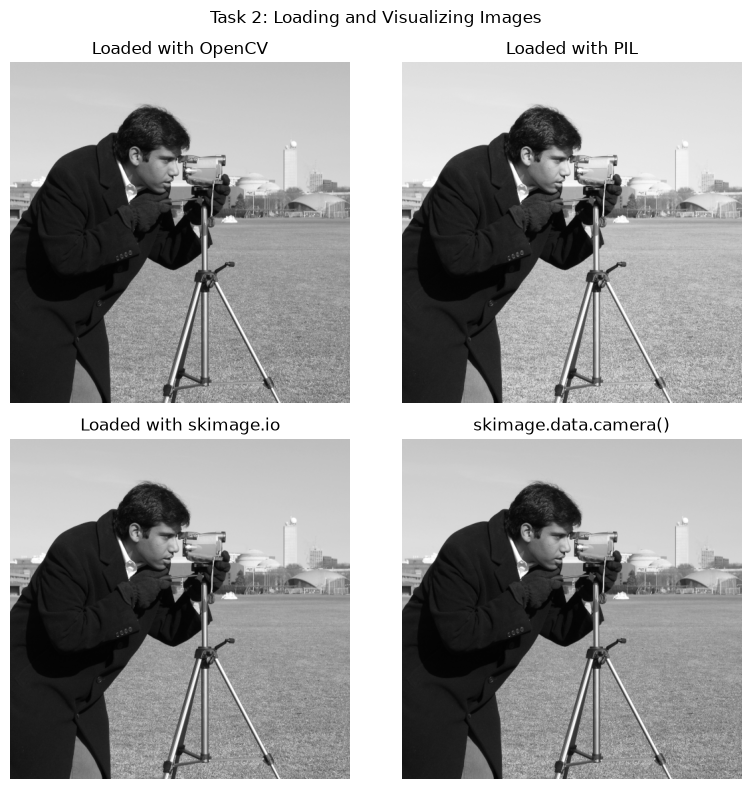

In [3]:
# Loading/reading an image using OpenCV
img_cv2 = cv2.imread(image_path)  # loaded as BGR NumPy array

# Loading/reading an image using PIL
img_pil = Image.open(image_path)

# Loading/reading an image using skimage
img_ski = ski.io.imread(image_path)

fig, axs = plt.subplots(2, 2, figsize=(8, 8))
fig.suptitle("Task 2: Loading and Visualizing Images")

axs[0, 0].imshow(cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB))
axs[0, 0].set_title("Loaded with OpenCV")

axs[0, 1].imshow(img_pil, cmap=cm.Greys_r)
axs[0, 1].set_title("Loaded with PIL")

axs[1, 0].imshow(img_ski, cmap=plt.cm.gray)
axs[1, 0].set_title("Loaded with skimage.io")

axs[1, 1].imshow(ski.data.camera(), cmap=plt.cm.gray)
axs[1, 1].set_title("skimage.data.camera()")

for ax in axs.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()


## Task #3: Image Storing


In [4]:
# Saving an image to disk using OpenCV
cv2.imwrite("new_image_cv2.jpg", img_cv2)

# Saving an image to disk using PIL
img_pil.save("new_image_pil.jpg")

# Saving an image to disk using skimage
ski.io.imsave("new_image_ski.jpg", img_ski)


## Task #4: Display image as an Array


In [5]:
print("OpenCV image shape:", img_cv2.shape)  # (H, W, 3) - BGR
print(img_cv2)

img_array = np.array(img_pil)
print("PIL image converted to NumPy array shape:", img_array.shape)
print(img_array)

print("skimage image (already a NumPy array) shape:", img_ski.shape)
print(img_ski)


OpenCV image shape: (512, 512, 3)
[[[200 200 200]
  [200 200 200]
  [200 200 200]
  ...
  [189 189 189]
  [190 190 190]
  [190 190 190]]

 [[200 200 200]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 [[199 199 199]
  [199 199 199]
  [199 199 199]
  ...
  [190 190 190]
  [190 190 190]
  [190 190 190]]

 ...

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [139 139 139]
  [122 122 122]
  [147 147 147]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 26  26  26]
  ...
  [158 158 158]
  [141 141 141]
  [168 168 168]]

 [[ 25  25  25]
  [ 25  25  25]
  [ 27  27  27]
  ...
  [151 151 151]
  [152 152 152]
  [149 149 149]]]
PIL image converted to NumPy array shape: (512, 512)
[[200 200 200 ... 189 190 190]
 [200 199 199 ... 190 190 190]
 [199 199 199 ... 190 190 190]
 ...
 [ 25  25  27 ... 139 122 147]
 [ 25  25  26 ... 158 141 168]
 [ 25  25  27 ... 151 152 149]]
skimage image (already a NumPy array) shape: (512, 512)
[[200 200 200 ... 189 190 190]
 [20

## Assessment: perform different operations on the array using NumPy



--- NumPy array operations on the skimage image ---
Shape: (512, 512)
Min / Max / Mean: 0.0 255.0 129.06072616577148


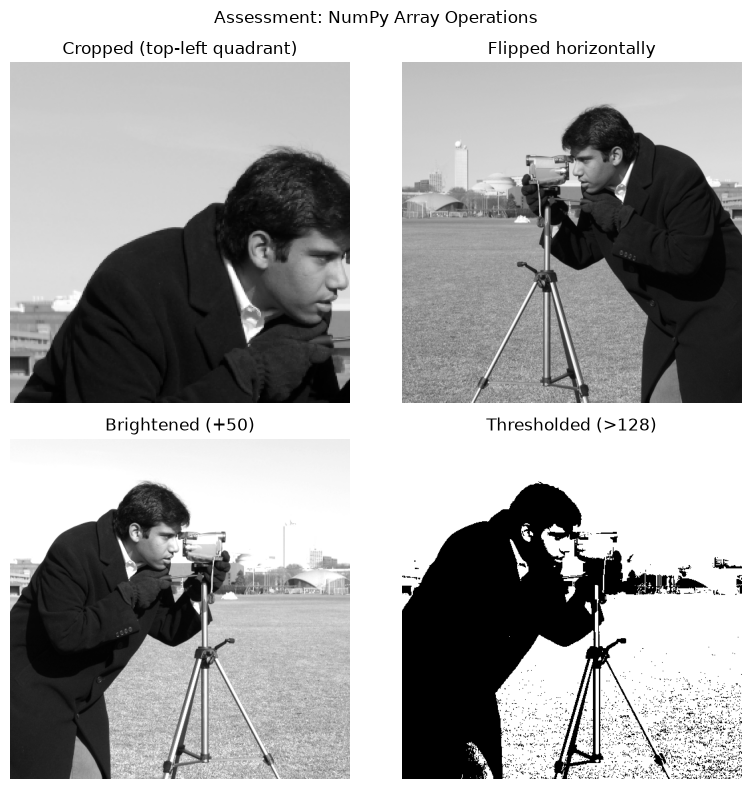

In [6]:
arr = img_ski.astype(np.float64)  # work on the grayscale skimage array

# 1. Basic statistics
print("\n--- NumPy array operations on the skimage image ---")
print("Shape:", arr.shape)
print("Min / Max / Mean:", arr.min(), arr.max(), arr.mean())

# 2. Cropping (top-left quadrant)
cropped = img_ski[: img_ski.shape[0] // 2, : img_ski.shape[1] // 2]

# 3. Flipping horizontally
flipped = np.fliplr(img_ski)

# 4. Brightness adjustment (add a constant, clip to valid range)
brightened = np.clip(arr + 50, 0, 255).astype(np.uint8)

# 5. Simple binary thresholding
thresholded = np.where(img_ski > 128, 255, 0).astype(np.uint8)

fig2, axs2 = plt.subplots(2, 2, figsize=(8, 8))
fig2.suptitle("Assessment: NumPy Array Operations")

axs2[0, 0].imshow(cropped, cmap=plt.cm.gray)
axs2[0, 0].set_title("Cropped (top-left quadrant)")

axs2[0, 1].imshow(flipped, cmap=plt.cm.gray)
axs2[0, 1].set_title("Flipped horizontally")

axs2[1, 0].imshow(brightened, cmap=plt.cm.gray)
axs2[1, 0].set_title("Brightened (+50)")

axs2[1, 1].imshow(thresholded, cmap=plt.cm.gray)
axs2[1, 1].set_title("Thresholded (>128)")

for ax in axs2.ravel():
    ax.axis("off")

plt.tight_layout()
plt.show()
